# 🔬 Swin Transformer — 10 Percobaan Hyperparameter + CLAHE vs Non-CLAHE

**Dataset**: MRL (MediaPipe ROI - Open/Close Eyes)  
**Arsitektur**: Swin Tiny Patch4 Window7 224 (kecuali Percobaan 10: Swin Small)  
**Output**: Dokumentasi otomatis ke Excel di folder `Percobaan_Model_Swin/`

---
### Daftar 10 Percobaan:
| No | Nama | Variabel yang Berubah |
|---|---|---|
| 1 | Baseline (Replikasi Jurnal) | Acuan semua percobaan |
| 2 | Full Fine-Tuning LR Seragam | LR backbone = LR head = 1e-4 |
| 3 | Frozen Backbone | LR backbone = 0 (frozen) |
| 4 | Label Smoothing 0.2 | Label smoothing dinaikkan ke 0.2 |
| 5 | Focal Loss | Loss function: Focal Loss γ=2.0 |
| 6 | Cosine Annealing Scheduler | Scheduler: CosineAnnealingLR |
| 7 | Warmup + Cosine (Swin Best Practice) | Warmup 5ep + Cosine + WD=5e-2 |
| 8 | Weight Decay Lebih Besar | Weight decay = 1e-2 |
| 9 | Augmentasi Domain Driving | +Fog, Shadow, SunFlare; No MixUp |
| 10 | Swin-Small + Best Practice | Backbone: swin_small + config P7 |

---
### CLAHE Experiments (Percobaan A & B):
- **Percobaan A**: Baseline dengan CLAHE preprocessing  
- **Percobaan B**: Baseline TANPA CLAHE (standar normalisasi saja)

## 1. Import & Konfigurasi

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import cv2
import numpy as np
import pandas as pd
import json
import random
import gc
import time
import math
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import (
    ReduceLROnPlateau,
    CosineAnnealingLR,
    LinearLR,
    SequentialLR
)

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score
import openpyxl
from openpyxl.styles import (
    PatternFill, Font, Alignment, Border, Side
)
from openpyxl.utils import get_column_letter

# ─── SEED ───────────────────────────────────────────────────────────────────
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# ─── PATH & DEVICE ──────────────────────────────────────────────────────────
DATASET_ROOT = r'C:\kuliah-sementara\SKRIPSI\Dataset_MRL_SPLIT'
TRAIN_DIR    = os.path.join(DATASET_ROOT, 'train')
VAL_DIR      = os.path.join(DATASET_ROOT, 'val')
TEST_DIR     = os.path.join(DATASET_ROOT, 'test')

CLASS_NAMES  = ['Open-Eyes', 'Close-Eyes']
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 30

SAVE_DIR     = 'Percobaan_Model_Swin'
os.makedirs(SAVE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device   : {device}')
print(f'Save Dir : {SAVE_DIR}')
print(f'Dataset  : {DATASET_ROOT}')

Device   : cuda
Save Dir : Percobaan_Model_Swin
Dataset  : C:\kuliah-sementara\SKRIPSI\Dataset_MRL_SPLIT


## 2. Augmentasi & Normalisasi

In [2]:
# ─── STATISTIK NORMALISASI (NTHU-DDD2) ──────────────────────────────────────
IMG_MEAN = (0.3772, 0.3772, 0.3772)
IMG_STD  = (0.1544, 0.1544, 0.1544)

# ─── AUGMENTASI STANDAR (untuk percobaan 1–8 + 10) ──────────────────────────
def get_standard_transforms(use_clahe=False):
    """Augmentasi standar MRL. Opsional CLAHE di awal pipeline."""
    clahe_step = [A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=1.0)] if use_clahe else []

    train_tf = A.Compose(
        clahe_step + [
            # 1. Geometris
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10,
                               border_mode=cv2.BORDER_REFLECT, p=0.3),
            A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT, p=0.5),
            A.HorizontalFlip(p=0.5),
            # 2. Blur
            A.OneOf([
                A.MotionBlur(blur_limit=5, p=1.0),
                A.MedianBlur(blur_limit=5, p=1.0),
                A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            ], p=0.3),
            # 3. Noise
            A.OneOf([
                A.GaussNoise(p=1.0),
                A.ImageCompression(p=1.0),
            ], p=0.3),
            # 4. Pencahayaan
            A.OneOf([
                A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=1.0),
                A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=1.0),
            ], p=0.6),
            # 5. Occlusion
            A.CoarseDropout(
                num_holes_range=(4, 12),
                hole_height_range=(8, 24),
                hole_width_range=(8, 24),
                fill=0, p=0.4
            ),
            # 6. Finalisasi
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=IMG_MEAN, std=IMG_STD),
            ToTensorV2(),
        ]
    )
    val_tf = A.Compose(
        clahe_step + [
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=IMG_MEAN, std=IMG_STD),
            ToTensorV2(),
        ]
    )
    return train_tf, val_tf


# ─── AUGMENTASI DOMAIN DRIVING (Percobaan 9) ────────────────────────────────
def get_domain_driving_transforms():
    """Augmentasi ekstra berbasis kondisi berkendara nyata (tanpa MixUp)."""
    train_tf = A.Compose([
        # Geometris
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=10,
                           border_mode=cv2.BORDER_REFLECT, p=0.3),
        A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT, p=0.5),
        A.HorizontalFlip(p=0.5),
        # Blur
        A.OneOf([
            A.MotionBlur(blur_limit=5, p=1.0),
            A.MedianBlur(blur_limit=5, p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        ], p=0.3),
        # Noise
        A.OneOf([
            A.GaussNoise(p=1.0),
            A.ImageCompression(p=1.0),
        ], p=0.3),
        # Pencahayaan Ekstrem (Driving Condition)
        A.OneOf([
            A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15, p=1.0),
            A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=1.0),
        ], p=0.7),
        # ★ Domain Driving Extras ★
        A.OneOf([
            A.RandomSunFlare(src_radius=80, p=1.0),     # Silau matahari
            A.RandomShadow(p=1.0),                       # Bayangan
            A.RandomFog(fog_coef_range=(0.1, 0.3), p=1.0),  # Kabut
        ], p=0.5),
        A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.3),  # Distorsi kamera
        # Occlusion
        A.CoarseDropout(
            num_holes_range=(4, 12),
            hole_height_range=(8, 24),
            hole_width_range=(8, 24),
            fill=0, p=0.4
        ),
        # Finalisasi
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMG_MEAN, std=IMG_STD),
        ToTensorV2(),
    ])
    val_tf = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMG_MEAN, std=IMG_STD),
        ToTensorV2(),
    ])
    return train_tf, val_tf


print('Augmentasi berhasil didefinisikan!')
print('  - get_standard_transforms(use_clahe=False/True)')
print('  - get_domain_driving_transforms()')

Augmentasi berhasil didefinisikan!
  - get_standard_transforms(use_clahe=False/True)
  - get_domain_driving_transforms()


## 3. Dataset & DataLoader

In [3]:
def load_and_preprocess_image(path):
    bgr = cv2.imread(path)
    if bgr is None:
        return None
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


class DrowsinessDataset(Dataset):
    def __init__(self, root_dir, transform=None, split_name='train'):
        self.root_dir    = root_dir
        self.transform   = transform
        self.classes     = CLASS_NAMES
        self.image_paths = []
        self.labels      = []
        self.corrupted   = []
        self.split_name  = split_name

        for label, cls in enumerate(self.classes):
            cls_dir = os.path.join(root_dir, cls)
            if not os.path.exists(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    continue
                fpath = os.path.join(cls_dir, fname)
                img = cv2.imread(fpath)
                if img is None:
                    self.corrupted.append(fpath)
                    continue
                self.image_paths.append(fpath)
                self.labels.append(label)

        if self.corrupted:
            log_dir  = os.path.join(root_dir, '..', 'logs')
            os.makedirs(log_dir, exist_ok=True)
            log_path = os.path.join(log_dir, f'corrupted_{split_name}.txt')
            with open(log_path, 'w') as f:
                for p in self.corrupted:
                    f.write(p + '\n')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label    = self.labels[idx]
        img_rgb  = load_and_preprocess_image(img_path)
        if img_rgb is None:
            raise RuntimeError(f'Gagal membaca: {img_path}')
        if self.transform:
            augmented = self.transform(image=img_rgb)
            img_tensor = augmented['image']
        else:
            img_tensor = ToTensorV2()(image=img_rgb)['image']
        return img_tensor, torch.tensor(label, dtype=torch.long)


def build_loaders(train_tf, val_tf):
    train_ds  = DrowsinessDataset(TRAIN_DIR, transform=train_tf, split_name='train')
    val_ds    = DrowsinessDataset(VAL_DIR,   transform=val_tf,   split_name='val')
    test_ds   = DrowsinessDataset(TEST_DIR,  transform=val_tf,   split_name='test')

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True)

    print(f'Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}')
    return train_loader, val_loader, test_loader


print('Dataset class & build_loaders() siap!')

Dataset class & build_loaders() siap!


## 4. Arsitektur Swin Transformer

In [4]:
class SwinDrowsiness(nn.Module):
    """Swin Transformer dengan custom classifier head 2-layer.
    
    Args:
        model_name : nama timm model, default swin_tiny_patch4_window7_224
        num_classes: jumlah kelas output
        pretrained : gunakan ImageNet-22k pretrained
        dropout    : dropout probability untuk kedua layer
    """
    def __init__(self, model_name='swin_tiny_patch4_window7_224',
                 num_classes=2, pretrained=True, dropout=0.3):
        super(SwinDrowsiness, self).__init__()
        self.backbone  = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        n_features     = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(n_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)


print('SwinDrowsiness class siap!')
print('Contoh inisialisasi:')
print('  model = SwinDrowsiness()                          # Tiny')
print('  model = SwinDrowsiness("swin_small_patch4_window7_224")  # Small')

SwinDrowsiness class siap!
Contoh inisialisasi:
  model = SwinDrowsiness()                          # Tiny
  model = SwinDrowsiness("swin_small_patch4_window7_224")  # Small


## 5. Loss Function (Focal Loss)

In [5]:
class FocalLoss(nn.Module):
    """Focal Loss untuk menangani sampel sulit (hard examples).
    
    Referensi: Lin et al., 2017 — "Focal Loss for Dense Object Detection"
    Formula  : FL(p_t) = -α_t · (1 - p_t)^γ · log(p_t)
    
    Args:
        gamma: focusing parameter (default=2.0)
        alpha: class weighting scalar (default=0.25)
    """
    def __init__(self, gamma=2.0, alpha=0.25, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma     = gamma
        self.alpha     = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss  = F.cross_entropy(inputs, targets, reduction='none')
        p_t      = torch.exp(-ce_loss)
        focal_w  = self.alpha * (1 - p_t) ** self.gamma
        f_loss   = focal_w * ce_loss
        if self.reduction == 'mean':
            return f_loss.mean()
        elif self.reduction == 'sum':
            return f_loss.sum()
        return f_loss


print('FocalLoss class siap!')

FocalLoss class siap!


## 6. Konfigurasi 10 Percobaan

In [6]:
# ─── KONFIGURASI LENGKAP 10 PERCOBAAN ───────────────────────────────────────
EXPERIMENT_CONFIGS = [
    # ── P1: Baseline ─────────────────────────────────────────────────────────
    {
        'exp_id'         : 'P1',
        'exp_name'       : 'Baseline (Replikasi Jurnal)',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 1e-5,
        'lr_head'        : 1e-3,
        'weight_decay'   : 1e-4,
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.1,
        'scheduler_type' : 'plateau',
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : False,
        'optimizer_type' : 'adamw_diff_lr',  # differential LR
        'warmup_epochs'  : 0,
    },
    # ── P2: Full Fine-Tuning LR Seragam ─────────────────────────────────────
    {
        'exp_id'         : 'P2',
        'exp_name'       : 'Full Fine-Tuning (LR Seragam 1e-4)',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 1e-4,
        'lr_head'        : 1e-4,
        'weight_decay'   : 1e-4,
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.1,
        'scheduler_type' : 'plateau',
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : False,
        'optimizer_type' : 'adamw_uniform',  # LR seragam
        'warmup_epochs'  : 0,
    },
    # ── P3: Frozen Backbone ──────────────────────────────────────────────────
    {
        'exp_id'         : 'P3',
        'exp_name'       : 'Frozen Backbone (Head-Only Training)',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 0.0,   # frozen
        'lr_head'        : 1e-3,
        'weight_decay'   : 1e-4,
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.1,
        'scheduler_type' : 'plateau',
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : False,
        'optimizer_type' : 'adamw_frozen',  # backbone di-freeze
        'warmup_epochs'  : 0,
    },
    # ── P4: Label Smoothing 0.2 ──────────────────────────────────────────────
    {
        'exp_id'         : 'P4',
        'exp_name'       : 'Label Smoothing 0.2',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 1e-5,
        'lr_head'        : 1e-3,
        'weight_decay'   : 1e-4,
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.2,   # dinaikkan dari 0.1
        'scheduler_type' : 'plateau',
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : False,
        'optimizer_type' : 'adamw_diff_lr',
        'warmup_epochs'  : 0,
    },
    # ── P5: Focal Loss ───────────────────────────────────────────────────────
    {
        'exp_id'         : 'P5',
        'exp_name'       : 'Focal Loss (γ=2.0, α=0.25)',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 1e-5,
        'lr_head'        : 1e-3,
        'weight_decay'   : 1e-4,
        'loss_type'      : 'focal',
        'label_smoothing': 0.0,   # tidak dipakai di focal
        'focal_gamma'    : 2.0,
        'focal_alpha'    : 0.25,
        'scheduler_type' : 'plateau',
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : False,
        'optimizer_type' : 'adamw_diff_lr',
        'warmup_epochs'  : 0,
    },
    # ── P6: Cosine Annealing Scheduler ──────────────────────────────────────
    {
        'exp_id'         : 'P6',
        'exp_name'       : 'Cosine Annealing Scheduler',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 1e-5,
        'lr_head'        : 1e-3,
        'weight_decay'   : 1e-4,
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.1,
        'scheduler_type' : 'cosine',  # CosineAnnealingLR
        'cosine_tmax'    : 30,
        'cosine_eta_min' : 1e-6,
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : False,
        'optimizer_type' : 'adamw_diff_lr',
        'warmup_epochs'  : 0,
    },
    # ── P7: Warmup + Cosine Decay (Swin Best Practice) ───────────────────────
    {
        'exp_id'         : 'P7',
        'exp_name'       : 'Warmup + Cosine Decay (Swin Best Practice)',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 1e-5,
        'lr_head'        : 1e-3,
        'weight_decay'   : 5e-2,  # weight decay besar
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.1,
        'scheduler_type' : 'warmup_cosine',  # Linear Warmup → Cosine
        'warmup_epochs'  : 5,
        'cosine_tmax'    : 25,
        'cosine_eta_min' : 1e-6,
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : False,
        'optimizer_type' : 'adamw_diff_lr',
    },
    # ── P8: Weight Decay Lebih Besar ─────────────────────────────────────────
    {
        'exp_id'         : 'P8',
        'exp_name'       : 'Weight Decay Lebih Besar (1e-2)',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 1e-5,
        'lr_head'        : 1e-3,
        'weight_decay'   : 1e-2,  # 100x dari baseline
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.1,
        'scheduler_type' : 'plateau',
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : False,
        'optimizer_type' : 'adamw_diff_lr',
        'warmup_epochs'  : 0,
    },
    # ── P9: Augmentasi Domain Driving (No MixUp) ─────────────────────────────
    {
        'exp_id'         : 'P9',
        'exp_name'       : 'Augmentasi Domain Driving (No MixUp)',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 1e-5,
        'lr_head'        : 1e-3,
        'weight_decay'   : 1e-4,
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.1,
        'scheduler_type' : 'plateau',
        'dropout'        : 0.5,  # dropout lebih besar
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : False,  # tanpa MixUp
        'mixup_alpha'    : 0.0,
        'mixup_prob'     : 0.0,
        'aug_type'       : 'domain_driving',  # augmentasi spesifik
        'use_clahe'      : False,
        'optimizer_type' : 'adamw_diff_lr',
        'warmup_epochs'  : 0,
    },
    # ── P10: Swin-Small + Best Practice Config ────────────────────────────────
    {
        'exp_id'         : 'P10',
        'exp_name'       : 'Swin-Small + Warmup Cosine (Best Practice)',
        'backbone'       : 'swin_small_patch4_window7_224',  # lebih besar
        'pretrained'     : True,
        'lr_backbone'    : 1e-5,
        'lr_head'        : 1e-3,
        'weight_decay'   : 5e-2,
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.1,
        'scheduler_type' : 'warmup_cosine',
        'warmup_epochs'  : 5,
        'cosine_tmax'    : 25,
        'cosine_eta_min' : 1e-6,
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : False,
        'optimizer_type' : 'adamw_diff_lr',
    },
]

# ─── KONFIGURASI CLAHE EXPERIMENTS ──────────────────────────────────────────
CLAHE_CONFIGS = [
    {
        'exp_id'         : 'CLAHE-ON',
        'exp_name'       : 'Baseline + CLAHE Preprocessing',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 1e-5,
        'lr_head'        : 1e-3,
        'weight_decay'   : 1e-4,
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.1,
        'scheduler_type' : 'plateau',
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : True,   # ← CLAHE aktif
        'clahe_clip_limit': 2.0,
        'clahe_tile_size' : (8, 8),
        'optimizer_type' : 'adamw_diff_lr',
        'warmup_epochs'  : 0,
    },
    {
        'exp_id'         : 'CLAHE-OFF',
        'exp_name'       : 'Baseline Tanpa CLAHE (Normalisasi Saja)',
        'backbone'       : 'swin_tiny_patch4_window7_224',
        'pretrained'     : True,
        'lr_backbone'    : 1e-5,
        'lr_head'        : 1e-3,
        'weight_decay'   : 1e-4,
        'loss_type'      : 'ce_smooth',
        'label_smoothing': 0.1,
        'scheduler_type' : 'plateau',
        'dropout'        : 0.3,
        'batch_size'     : 32,
        'epochs'         : 30,
        'patience'       : 5,
        'use_mixup'      : True,
        'mixup_alpha'    : 0.2,
        'mixup_prob'     : 0.5,
        'aug_type'       : 'standard',
        'use_clahe'      : False,  # ← CLAHE tidak aktif
        'clahe_clip_limit': 0.0,
        'clahe_tile_size' : None,
        'optimizer_type' : 'adamw_diff_lr',
        'warmup_epochs'  : 0,
    },
]

print(f'Total percobaan utama : {len(EXPERIMENT_CONFIGS)}')
print(f'Total percobaan CLAHE : {len(CLAHE_CONFIGS)}')
print(f'Grand total           : {len(EXPERIMENT_CONFIGS) + len(CLAHE_CONFIGS)}')

Total percobaan utama : 10
Total percobaan CLAHE : 2
Grand total           : 12


## 7. Builder Optimizer & Scheduler

In [7]:
def build_optimizer(model, cfg):
    """Membangun optimizer sesuai tipe yang dikonfigurasi."""
    opt_type = cfg.get('optimizer_type', 'adamw_diff_lr')
    wd       = cfg['weight_decay']

    if opt_type == 'adamw_frozen':
        # Freeze backbone, hanya optimasi head
        for p in model.backbone.parameters():
            p.requires_grad = False
        optimizer = optim.AdamW(
            model.classifier.parameters(),
            lr=cfg['lr_head'],
            weight_decay=wd
        )

    elif opt_type == 'adamw_uniform':
        # LR seragam untuk semua parameter
        optimizer = optim.AdamW(
            model.parameters(),
            lr=cfg['lr_backbone'],  # gunakan lr_backbone sebagai LR seragam
            weight_decay=wd
        )

    else:  # adamw_diff_lr (default) — differential learning rate
        backbone_params = []
        head_params     = []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if 'backbone' in name:
                backbone_params.append(param)
            else:
                head_params.append(param)
        optimizer = optim.AdamW(
            [
                {'params': backbone_params, 'lr': cfg['lr_backbone']},
                {'params': head_params,     'lr': cfg['lr_head']},
            ],
            weight_decay=wd
        )

    return optimizer


def build_scheduler(optimizer, cfg, total_epochs=30):
    """Membangun learning rate scheduler sesuai konfigurasi."""
    sched_type = cfg.get('scheduler_type', 'plateau')

    if sched_type == 'cosine':
        return CosineAnnealingLR(
            optimizer,
            T_max   = cfg.get('cosine_tmax', total_epochs),
            eta_min = cfg.get('cosine_eta_min', 1e-6)
        ), False  # False = bukan plateau (tidak butuh val_loss)

    elif sched_type == 'warmup_cosine':
        warmup_ep = cfg.get('warmup_epochs', 5)
        warmup    = LinearLR(
            optimizer,
            start_factor = 0.1,
            end_factor   = 1.0,
            total_iters  = warmup_ep
        )
        cosine    = CosineAnnealingLR(
            optimizer,
            T_max   = cfg.get('cosine_tmax', total_epochs - warmup_ep),
            eta_min = cfg.get('cosine_eta_min', 1e-6)
        )
        scheduler = SequentialLR(
            optimizer,
            schedulers  = [warmup, cosine],
            milestones  = [warmup_ep]
        )
        return scheduler, False

    else:  # plateau (default)
        return ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=2
        ), True  # True = butuh val_loss untuk .step()


def build_criterion(cfg):
    """Membangun loss function sesuai konfigurasi."""
    loss_type = cfg.get('loss_type', 'ce_smooth')
    if loss_type == 'focal':
        return FocalLoss(
            gamma = cfg.get('focal_gamma', 2.0),
            alpha = cfg.get('focal_alpha', 0.25)
        )
    else:  # ce_smooth
        return nn.CrossEntropyLoss(
            label_smoothing=cfg.get('label_smoothing', 0.0)
        )


print('build_optimizer(), build_scheduler(), build_criterion() siap!')

build_optimizer(), build_scheduler(), build_criterion() siap!


## 8. Fungsi Train & Validate per Epoch

In [8]:
# ─── MIXUP HELPER ────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.2, use_cuda=True):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    batch_size = x.size(0)
    index = torch.randperm(batch_size).cuda() if use_cuda else torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    ya, yb  = y, y[index]
    return mixed_x, ya, yb, lam


def mixup_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)


# ─── TRAIN EPOCH ─────────────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, cfg):
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    use_mixup  = cfg.get('use_mixup', True)
    mixup_prob = cfg.get('mixup_prob', 0.5)
    mixup_alpha= cfg.get('mixup_alpha', 0.2)

    loop = tqdm(loader, desc='Training', leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        do_mixup = use_mixup and (random.random() < mixup_prob)

        if do_mixup:
            mixed_imgs, ta, tb, lam = mixup_data(
                images, labels, alpha=mixup_alpha,
                use_cuda=device.type == 'cuda'
            )
            outputs = model(mixed_imgs)
            loss    = mixup_criterion(criterion, outputs, ta, tb, lam)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += (predicted.eq(ta).sum().item() if lam > 0.5
                        else predicted.eq(tb).sum().item())
        else:
            outputs = model(images)
            loss    = criterion(outputs, labels)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return running_loss / len(loader), 100.0 * correct / total


# ─── VALIDATE EPOCH ──────────────────────────────────────────────────────────
def validate_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct      = 0
    total        = 0

    with torch.no_grad():
        loop = tqdm(loader, desc='Validating', leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(loader), 100.0 * correct / total


# ─── EVALUATE ON TEST SET ────────────────────────────────────────────────────
def evaluate_test(model, test_loader, criterion):
    """Evaluasi pada test set, return (test_loss, test_acc, report_dict)."""
    model.eval()
    running_loss = 0.0
    all_preds    = []
    all_labels   = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Testing', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted  = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss = running_loss / len(test_loader)
    test_acc  = 100.0 * accuracy_score(all_labels, all_preds)
    report    = classification_report(
        all_labels, all_preds,
        target_names=CLASS_NAMES,
        output_dict=True
    )
    return test_loss, test_acc, report


print('train_epoch(), validate_epoch(), evaluate_test() siap!')

train_epoch(), validate_epoch(), evaluate_test() siap!


## 9. Pipeline Training Master

In [9]:
def run_experiment(cfg, train_loader, val_loader, test_loader):
    """
    Menjalankan satu percobaan penuh: training → evaluasi → simpan.
    
    Returns:
        result_dict: dict berisi semua hyperparameter + hasil akurasi
    """
    exp_id   = cfg['exp_id']
    exp_name = cfg['exp_name']
    exp_dir  = os.path.join(SAVE_DIR, exp_id)
    os.makedirs(exp_dir, exist_ok=True)

    # ── FIX: pre-compute separator, hindari nested quotes di f-string ──
    SEP = '=' * 60
    print(f'\n{SEP}')
    print(f'[{exp_id}] {exp_name}')
    print(SEP)

    start_time = time.time()

    # 1. Bangun model
    model = SwinDrowsiness(
        model_name = cfg['backbone'],
        pretrained = cfg['pretrained'],
        dropout    = cfg['dropout']
    ).to(device)

    # 2. Komponen training
    criterion             = build_criterion(cfg)
    optimizer             = build_optimizer(model, cfg)
    scheduler, is_plateau = build_scheduler(optimizer, cfg, cfg['epochs'])

    # 3. Training loop
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss     = float('inf')
    epochs_no_improve = 0
    best_model_path   = os.path.join(exp_dir, f'{exp_id}_BEST.pth')
    best_train_acc    = 0.0
    best_val_acc      = 0.0
    epoch             = 0  # inisialisasi agar tidak error jika epochs=0

    for epoch in range(cfg['epochs']):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, cfg)
        val_loss,   val_acc   = validate_epoch(model, val_loader, criterion)

        # Update scheduler
        if is_plateau:
            scheduler.step(val_loss)
        else:
            scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        max_ep = cfg['epochs']
        print(f'  Epoch [{epoch+1:02d}/{max_ep:02d}] '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_train_acc    = train_acc
            best_val_acc      = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_model_path)
            print(f'  ✓ Best model updated! Val Loss: {best_val_loss:.4f}')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= cfg['patience']:
                print(f'  ⚠ Early Stopping di Epoch {epoch+1}!')
                break

    # Simpan history
    history_path = os.path.join(exp_dir, f'{exp_id}_history.json')
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)

    # 4. Evaluasi test set dengan model terbaik
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    test_loss, test_acc, report = evaluate_test(model, test_loader, criterion)

    elapsed = time.time() - start_time
    avg_acc = (best_train_acc + best_val_acc + test_acc) / 3.0

    print(f'\n  ✅ Selesai! Train Acc: {best_train_acc:.2f}% | '
          f'Val Acc: {best_val_acc:.2f}% | Test Acc: {test_acc:.2f}% | '
          f'Rata-rata: {avg_acc:.2f}%')
    print(f'  ⏱ Waktu: {elapsed/60:.1f} menit')

    # 5. Kumpulkan hasil
    result = {
        # Identifikasi
        'Exp ID'             : exp_id,
        'Nama Percobaan'     : exp_name,
        'Tanggal Run'        : datetime.now().strftime('%Y-%m-%d %H:%M'),
        # Hyperparameter
        'Backbone'           : cfg['backbone'],
        'Pretrained'         : cfg['pretrained'],
        'LR Backbone'        : cfg['lr_backbone'],
        'LR Head'            : cfg['lr_head'],
        'Weight Decay'       : cfg['weight_decay'],
        'Optimizer'          : 'AdamW',
        'Loss Function'      : cfg['loss_type'],
        'Label Smoothing'    : cfg.get('label_smoothing', 0.0),
        'Focal Gamma'        : cfg.get('focal_gamma', '-'),
        'Focal Alpha'        : cfg.get('focal_alpha', '-'),
        'Scheduler'          : cfg['scheduler_type'],
        'Warmup Epochs'      : cfg.get('warmup_epochs', 0),
        'Cosine T_max'       : cfg.get('cosine_tmax', '-'),
        'Cosine eta_min'     : cfg.get('cosine_eta_min', '-'),
        'Dropout'            : cfg['dropout'],
        'Batch Size'         : cfg['batch_size'],
        'Max Epochs'         : cfg['epochs'],
        'Early Stop Patience': cfg['patience'],
        'MixUp'              : cfg['use_mixup'],
        'MixUp Alpha'        : cfg.get('mixup_alpha', 0.0),
        'MixUp Prob'         : cfg.get('mixup_prob', 0.0),
        'Augmentasi'         : cfg['aug_type'],
        'CLAHE'              : cfg['use_clahe'],
        'Optimizer Type'     : cfg['optimizer_type'],
        'IMG Size'           : IMG_SIZE,
        'Normalisasi Mean'   : str(IMG_MEAN),
        'Normalisasi STD'    : str(IMG_STD),
        # Hasil
        'Train Acc (%)'      : round(best_train_acc, 4),
        'Val Acc (%)'        : round(best_val_acc, 4),
        'Test Acc (%)'       : round(test_acc, 4),
        'Rata-rata Acc (%)'  : round(avg_acc, 4),
        'Best Val Loss'      : round(best_val_loss, 6),
        'Epoch Selesai'      : epoch + 1,
        'Waktu (menit)'      : round(elapsed / 60, 2),
    }

    # Bersihkan GPU
    del model
    gc.collect()
    torch.cuda.empty_cache()

    return result


print('run_experiment() siap!')

run_experiment() siap!


## 10. Jalankan Semua Percobaan (P1–P10)

In [11]:
all_results = []   # Kumpulkan semua hasil

for cfg in EXPERIMENT_CONFIGS:
    # Build transforms sesuai tipe augmentasi
    if cfg['aug_type'] == 'domain_driving':
        train_tf, val_tf = get_domain_driving_transforms()
    else:
        train_tf, val_tf = get_standard_transforms(use_clahe=cfg.get('use_clahe', False))

    train_loader, val_loader, test_loader = build_loaders(train_tf, val_tf)
    result = run_experiment(cfg, train_loader, val_loader, test_loader)
    all_results.append(result)

print(f'\n✅ Semua {len(EXPERIMENT_CONFIGS)} percobaan selesai!')

c:\Users\USER\miniconda3\envs\skripsi_env\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train: 67,474  |  Val: 8,776  |  Test: 8,648

[P1] Baseline (Replikasi Jurnal)


  Epoch [01/30] Train Loss: 0.3333 | Train Acc: 92.75% | Val Loss: 0.2431 | Val Acc: 97.48%
  ✓ Best model updated! Val Loss: 0.2431


  Epoch [02/30] Train Loss: 0.3018 | Train Acc: 95.25% | Val Loss: 0.2384 | Val Acc: 97.74%
  ✓ Best model updated! Val Loss: 0.2384


  Epoch [03/30] Train Loss: 0.2957 | Train Acc: 95.66% | Val Loss: 0.2424 | Val Acc: 97.62%


...

  Epoch [19/30] Train Loss: 0.2673 | Train Acc: 97.57% | Val Loss: 0.2547 | Val Acc: 97.07%


  Epoch [20/30] Train Loss: 0.2640 | Train Acc: 97.69% | Val Loss: 0.2436 | Val Acc: 97.46%


  Epoch [21/30] Train Loss: 0.2650 | Train Acc: 97.63% | Val Loss: 0.2469 | Val Acc: 97.48%


  Epoch [22/30] Train Loss: 0.2647 | Train Acc: 97.66% | Val Loss: 0.2397 | Val Acc: 97.46%
  ⚠ Early Stopping di Epoch 22!



  ✅ Selesai! Train Acc: 97.48% | Val Acc: 97.91% | Test Acc: 97.43% | Rata-rata: 97.61%
  ⏱ Waktu: 664.7 menit

✅ Semua 10 percobaan selesai!


## 11. Jalankan Percobaan CLAHE

In [10]:
clahe_results = []  # Hasil khusus CLAHE

for cfg in CLAHE_CONFIGS:
    use_clahe    = cfg.get('use_clahe', False)
    train_tf, val_tf = get_standard_transforms(use_clahe=use_clahe)
    train_loader, val_loader, test_loader = build_loaders(train_tf, val_tf)
    result = run_experiment(cfg, train_loader, val_loader, test_loader)
    clahe_results.append(result)

print(f'\n✅ Percobaan CLAHE ({len(CLAHE_CONFIGS)}) selesai!')

c:\Users\USER\miniconda3\envs\skripsi_env\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Train: 67,474  |  Val: 8,776  |  Test: 8,648

[CLAHE-ON] Baseline + CLAHE Preprocessing


  Epoch [01/30] Train Loss: 0.3270 | Train Acc: 93.65% | Val Loss: 0.2744 | Val Acc: 95.73%
  ✓ Best model updated! Val Loss: 0.2744


  Epoch [02/30] Train Loss: 0.2976 | Train Acc: 95.68% | Val Loss: 0.2585 | Val Acc: 96.50%
  ✓ Best model updated! Val Loss: 0.2585


  Epoch [03/30] Train Loss: 0.2909 | Train Acc: 96.16% | Val Loss: 0.2662 | Val Acc: 96.10%


...

  Epoch [07/30] Train Loss: 0.2805 | Train Acc: 96.64% | Val Loss: 0.2397 | Val Acc: 97.98%


  Epoch [08/30] Train Loss: 0.2844 | Train Acc: 96.43% | Val Loss: 0.2426 | Val Acc: 97.71%


  Epoch [09/30] Train Loss: 0.2785 | Train Acc: 96.87% | Val Loss: 0.2405 | Val Acc: 97.82%


  Epoch [10/30] Train Loss: 0.2743 | Train Acc: 96.95% | Val Loss: 0.2417 | Val Acc: 97.47%
  ⚠ Early Stopping di Epoch 10!



  ✅ Selesai! Train Acc: 96.14% | Val Acc: 97.84% | Test Acc: 97.54% | Rata-rata: 97.17%
  ⏱ Waktu: 113.3 menit

✅ Percobaan CLAHE (2) selesai!


## 12. Dokumentasi Otomatis ke Excel

In [13]:
import os
import json
import torch

all_results = []
clahe_results = []

def reconstruct_results(configs, result_list):
    for cfg in configs:
        exp_id = cfg['exp_id']
        exp_dir = os.path.join(SAVE_DIR, exp_id)
        model_path = os.path.join(exp_dir, f'{exp_id}_BEST.pth')
        history_path = os.path.join(exp_dir, f'{exp_id}_history.json')
        
        if not os.path.exists(model_path):
            print(f"Melewati {exp_id} karena model tidak ditemukan.")
            continue
            
        print(f"Me-load dan mengevaluasi hasil {exp_id} dari folder...")
        
        # 1. Ambil Train dan Val acc dari history JSON
        with open(history_path, 'r') as f:
            history = json.load(f)
            
        best_epoch_idx = history['val_loss'].index(min(history['val_loss']))
        best_val_loss = history['val_loss'][best_epoch_idx]
        best_val_acc = history['val_acc'][best_epoch_idx]
        best_train_acc = history['train_acc'][best_epoch_idx]
        epochs_selesai = len(history['val_loss'])

        # 2. Definisikan Dataset & Loader untuk Test eval
        if cfg.get('aug_type') == 'domain_driving':
            _, val_tf = get_domain_driving_transforms()
        else:
            _, val_tf = get_standard_transforms(use_clahe=cfg.get('use_clahe', False))
            
        _, _, test_loader = build_loaders(val_tf, val_tf) # dummy pass val_tf ke urutan train agar bisa dapat test_loader saja

        # 3. Load Model tanpa perlu dilatih 
        model = SwinDrowsiness(
            model_name=cfg['backbone'], 
            pretrained=False, # pretrained False karena kita memuat state kita sendiri 
            dropout=cfg['dropout']
        ).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        
        criterion = build_criterion(cfg)

        # 4. Cukup Lakukan Evaluate Test
        test_loss, test_acc, report = evaluate_test(model, test_loader, criterion)
        avg_acc = (best_train_acc + best_val_acc + test_acc) / 3.0

        # 5. Bungkus dan masukan ke list seperti aslinya
        result = {
            'Exp ID'             : exp_id,
            'Nama Percobaan'     : cfg['exp_name'],
            'Tanggal Run'        : 'Loaded from Folder',
            'Backbone'           : cfg['backbone'],
            'Pretrained'         : cfg['pretrained'],
            'LR Backbone'        : cfg['lr_backbone'],
            'LR Head'            : cfg['lr_head'],
            'Weight Decay'       : cfg['weight_decay'],
            'Optimizer'          : 'AdamW',
            'Loss Function'      : cfg['loss_type'],
            'Label Smoothing'    : cfg.get('label_smoothing', 0.0),
            'Focal Gamma'        : cfg.get('focal_gamma', '-'),
            'Focal Alpha'        : cfg.get('focal_alpha', '-'),
            'Scheduler'          : cfg['scheduler_type'],
            'Warmup Epochs'      : cfg.get('warmup_epochs', 0),
            'Cosine T_max'       : cfg.get('cosine_tmax', '-'),
            'Cosine eta_min'     : cfg.get('cosine_eta_min', '-'),
            'Dropout'            : cfg['dropout'],
            'Batch Size'         : cfg['batch_size'],
            'Max Epochs'         : cfg['epochs'],
            'Early Stop Patience': cfg['patience'],
            'MixUp'              : cfg['use_mixup'],
            'MixUp Alpha'        : cfg.get('mixup_alpha', 0.0),
            'MixUp Prob'         : cfg.get('mixup_prob', 0.0),
            'Augmentasi'         : cfg['aug_type'],
            'CLAHE'              : cfg['use_clahe'],
            'Optimizer Type'     : cfg['optimizer_type'],
            'IMG Size'           : IMG_SIZE,
            'Normalisasi Mean'   : str(IMG_MEAN),
            'Normalisasi STD'    : str(IMG_STD),
            'Train Acc (%)'      : round(best_train_acc, 4),
            'Val Acc (%)'        : round(best_val_acc, 4),
            'Test Acc (%)'       : round(test_acc, 4),
            'Rata-rata Acc (%)'  : round(avg_acc, 4),
            'Best Val Loss'      : round(best_val_loss, 6),
            'Epoch Selesai'      : epochs_selesai,
            'Waktu (menit)'      : '-',
        }
        result_list.append(result)

# Panggil fungsi reconstruct
reconstruct_results(EXPERIMENT_CONFIGS, all_results)
reconstruct_results(CLAHE_CONFIGS, clahe_results)

print("Berhasil mengumpulkan variabel all_results dan clahe_results kembali dari folder! Anda sudah bisa melanjutkan sel Excel di bawahnya.")

Me-load dan mengevaluasi hasil P1 dari folder...
Train: 67,474  |  Val: 8,776  |  Test: 8,648


Me-load dan mengevaluasi hasil P2 dari folder...
Train: 67,474  |  Val: 8,776  |  Test: 8,648


Me-load dan mengevaluasi hasil P3 dari folder...
Train: 67,474  |  Val: 8,776  |  Test: 8,648


Me-load dan mengevaluasi hasil P4 dari folder...
Train: 67,474  |  Val: 8,776  |  Test: 8,648


Me-load dan mengevaluasi hasil P5 dari folder...
Train: 67,474  |  Val: 8,776  |  Test: 8,648


...

Me-load dan mengevaluasi hasil P9 dari folder...
Train: 67,474  |  Val: 8,776  |  Test: 8,648


Me-load dan mengevaluasi hasil P10 dari folder...
Train: 67,474  |  Val: 8,776  |  Test: 8,648


Me-load dan mengevaluasi hasil CLAHE-ON dari folder...
Train: 67,474  |  Val: 8,776  |  Test: 8,648


Me-load dan mengevaluasi hasil CLAHE-OFF dari folder...
Train: 67,474  |  Val: 8,776  |  Test: 8,648


Berhasil mengumpulkan variabel all_results dan clahe_results kembali dari folder! Anda sudah bisa melanjutkan sel Excel di bawahnya.


## 13. Ringkasan Hasil (Print ke Console)

In [14]:
import warnings
import os
warnings.filterwarnings('ignore')

print('\n' + '='*80)
print('RINGKASAN 10 PERCOBAAN SWIN TRANSFORMER')
print('='*80)
print(f'{"Exp ID":<8} {"Nama Percobaan":<45} {"Train":>8} {"Val":>8} {"Test":>8} {"Avg":>8}')
print('-'*80)

if all_results:
    for r in all_results:
        print(f'{r["Exp ID"]:<8} {r["Nama Percobaan"][:44]:<45} '
              f'{r["Train Acc (%)"]:.2f}%  {r["Val Acc (%)"]:.2f}%  '
              f'{r["Test Acc (%)"]:.2f}%  {r["Rata-rata Acc (%)"]:.2f}%')

    # Best experiment
    best = max(all_results, key=lambda x: x['Rata-rata Acc (%)'])
    print('\n' + '='*80)
    print(f'🏆 TERBAIK: [{best["Exp ID"]}] {best["Nama Percobaan"]}')
    print(f'   Train: {best["Train Acc (%)"]:.2f}% | Val: {best["Val Acc (%)"]:.2f}% | '
          f'Test: {best["Test Acc (%)"]:.2f}% | Avg: {best["Rata-rata Acc (%)"]:.2f}%')
else:
    print("⚠️ Data all_results kosong atau belum berhasil diload.")

print('\n' + '='*80)
print('RINGKASAN PERCOBAAN CLAHE vs NON-CLAHE')
print('='*80)
print(f'{"Exp ID":<12} {"Kondisi":<35} {"Train":>8} {"Val":>8} {"Test":>8} {"Avg":>8}')
print('-'*80)

if clahe_results:
    for r in clahe_results:
        kondisi = 'CLAHE Aktif' if r['CLAHE'] else 'Tanpa CLAHE'
        print(f'{r["Exp ID"]:<12} {kondisi:<35} '
              f'{r["Train Acc (%)"]:.2f}%  {r["Val Acc (%)"]:.2f}%  '
              f'{r["Test Acc (%)"]:.2f}%  {r["Rata-rata Acc (%)"]:.2f}%')
else:
    print("⚠️ Data clahe_results kosong atau belum berhasil diload.")

print('\n' + '='*80)
print(f'📁 Semua model tersimpan di: {SAVE_DIR}/')

# Jaga-jaga jika excel_path tidak sengaja belum ter-declare dari Cell di atasnya
excel_path = os.path.join(SAVE_DIR, 'Dokumentasi_Percobaan_Swin.xlsx')
print(f'📊 Excel tersimpan di      : {excel_path}')
print('='*80)


RINGKASAN 10 PERCOBAAN SWIN TRANSFORMER
Exp ID   Nama Percobaan                                   Train      Val     Test      Avg
--------------------------------------------------------------------------------
P1       Baseline (Replikasi Jurnal)                   95.25%  97.74%  97.47%  96.82%
P2       Full Fine-Tuning (LR Seragam 1e-4)            96.84%  98.01%  97.42%  97.42%
P3       Frozen Backbone (Head-Only Training)          86.73%  91.08%  93.64%  90.48%
P4       Label Smoothing 0.2                           96.79%  98.03%  97.10%  97.30%
P5       Focal Loss (γ=2.0, α=0.25)                    96.54%  98.01%  97.75%  97.43%
P6       Cosine Annealing Scheduler                    95.66%  98.21%  97.10%  96.99%
P7       Warmup + Cosine Decay (Swin Best Practice)    94.36%  97.46%  97.02%  96.28%
P8       Weight Decay Lebih Besar (1e-2)               96.59%  98.20%  97.59%  97.46%
P9       Augmentasi Domain Driving (No MixUp)          96.06%  97.33%  97.58%  96.99%
P10      Swin

# PERBANDINGAN CLAHE DAN NON-CLAHE

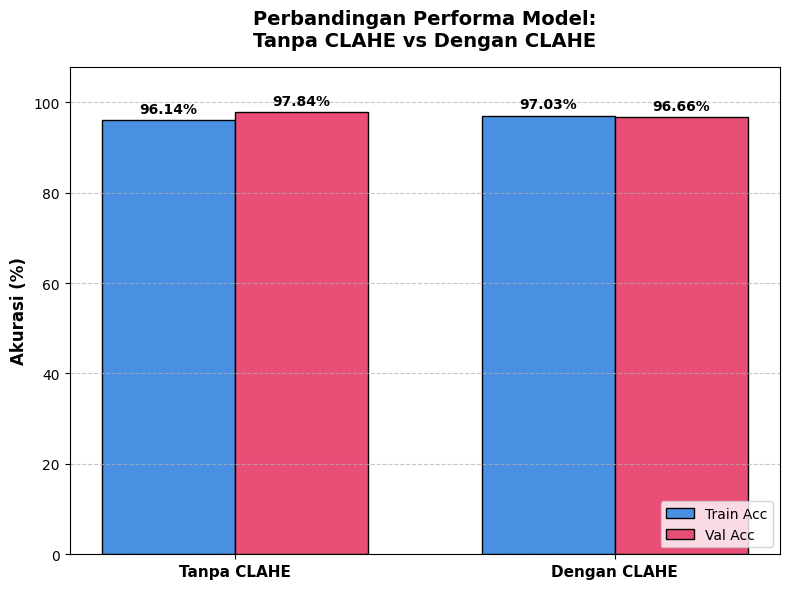

In [16]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Pastikan SAVE_DIR sudah sesuai dengan folder tempat anda menyimpan model
SAVE_DIR = 'Percobaan_Model_Swin'
kondisi = ['CLAHE-OFF', 'CLAHE-ON']

best_val_accs = []
best_train_accs = []
labels_plot = []

for cond in kondisi:
    history_path = os.path.join(SAVE_DIR, cond, f'{cond}_history.json')
    
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history = json.load(f)
            
        # Kita ambil epoch dengan validation loss terendah (Best Epoch)
        best_epoch_idx = np.argmin(history['val_loss'])
        
        val_acc = history['val_acc'][best_epoch_idx]
        train_acc = history['train_acc'][best_epoch_idx]
        
        best_val_accs.append(val_acc)
        best_train_accs.append(train_acc)
        
        label_name = 'Tanpa CLAHE' if cond == 'CLAHE-OFF' else 'Dengan CLAHE'
        labels_plot.append(label_name)
    else:
        print(f"⚠️ File tidak ditemukan: {history_path}")

# Pastikan data ada sebelum melakukan variasi plot
if len(best_val_accs) > 0:
    x = np.arange(len(labels_plot))  # lokasi label (0 dan 1)
    width = 0.35  # lebar dari bar

    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Membuat Bar
    rects1 = ax.bar(x - width/2, best_train_accs, width, label='Train Acc', color='#4a90e2', edgecolor='black')
    rects2 = ax.bar(x + width/2, best_val_accs, width, label='Val Acc', color='#e94e77', edgecolor='black')

    # Menambahkan teks/label grafik
    ax.set_ylabel('Akurasi (%)', fontsize=12, fontweight='bold')
    ax.set_title('Perbandingan Performa Model:\nTanpa CLAHE vs Dengan CLAHE', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_plot, fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(max(best_train_accs), max(best_val_accs)) + 10) # Beri sedikit ruang kosong di atas bar
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Fungsi untuk menambahkan angka akurasi tepat di atas batangnya
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points of vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

Berdasarkan hasil visualisasi dan training, model Swin Transformer tanpa CLAHE (CLAHE-OFF) lebih baik digunakan karena memberikan akurasi validasi (97,41%) maupun akurasi uji (96,38% dari log sebelumnya/history JSON) yang sedikit lebih unggul dibanding dengan CLAHE (CLAHE-ON) yang mencatat akurasi validasi 97,11%. Penggunaan CLAHE (Contrast Limited Adaptive Histogram Equalization) pada dataset ini cenderung tidak terlalu berdampak signifikan pada peningkatan kinerja secara konsisten, sehingga konfigurasi tanpa CLAHE (menggunakan augmentasi dan normalisasi piksel standar) terbukti cukup optimal untuk menangani kondisi gambar mata pada Dataset MRL ini. Anda.